## How to Make Topounits
Topounits are effectively sub-delineations of a grid cell within ELM. Within ELM, Topounits provide the capability to pass lateral (hydrologic) fluxes between themselves, which is a capability that does not exist between grid cells. Some parameters in ELM must be provided at the Topounit scale, so their delineation is necessary in order to sample these parameters appropriately.

### How are Topounits defined?

The idea driving Topounits is that different portions of a landscape (grid cell) may undergo different trajectories of evolution. Topounits are intended to allow a representation of this within-cell heterogeneity. However, there is no prescribed definition for Topounits, and different definitions may be relevant for different types of ELM experiments. Given that Topounits allow for lateral flux exchanges, it makes sense to develop some simple definitions based on digital elevation models (DEMs). Aspect may also dictate the dynamics of landscape trajectories in the Arctic due to differential solar radiations on North versus South facing slopes, for example. `dapper` currently contains two ways to define Topounits: elevation bands and elevation bands + aspect. Other methods are possible, so if you have ideas please open an issue in this repo or reach out. It could be possible to delineate topounits based on historic meteorological data, snow observations, height above nearest drainage, etc. One of the "hard" constraints is that the maximum number of topounits per grid cell is 11. As far as I understand, this was an E3SM-required constraint, but I also believe that it's possible to relax this number in offline ELM runs (don't quote me).  `dapper` does not constrain the number of Topounits you can generate for a given geometry.

### This notebook demonstrates

- **[A. Setup](#a-setup)**
- **[B. Quickstart — Elevation percentiles (equal-area)](#b-quickstart-elevation-percentiles-equal-area)**
- **[C. Understanding outputs](#c-understanding-outputs)**
- **[D. Visualizing Topounits](#d-visualizing-topounits)**
- **[E. Binning options](#e-binning-options)**
- **[F. Use your own dataset (GEE image)](#f-use-your-own-dataset-gee-image)**
- **[G. Combining datasets to define Topounits](#g-combining-datasets-to-define-topounits)**

and discusses some of the options you have and potential pitfalls along the way.

<div style="border: 2px solid #007ACC; background-color: #EAF4FF; padding: 10px; border-radius: 5px;">
<strong>💡 Note:</strong> You need a Google Earth Engine account to run this notebook.
</div>

## A. Setup

### 🔐 Initialize Earth Engine (use *your* Google Cloud project)

> You **must** set `project=your-google-cloud-project` to your own GCP project that has Earth Engine enabled in the `ee.Initialize()` call below.

In [ ]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# dapper utilities
from dapper.utils import gee_utils as gu
from dapper.topounit.topomake import make_topounits
import dapper.topounit.topoplot as tplt  # your plotting helpers

# Pretty pandas
import pandas as pd
pd.set_option("display.max_colwidth", 120)

# Initialize EE (use your own GCP project)
ee.Initialize(project='ee-jonschwenk')

### AOI (Kuparuk watershed)
You can swap this for any Feature / FeatureCollection / Geometry. Note that Topounit creation is designed to only handle one geometry at a time, so you may need to build a `for`-loop if you want a bunch (or open an Issue to have it supported by `dapper`).


In [4]:
# Load shared asset (FeatureCollection → first feature → Feature)
feature = ee.Feature(ee.FeatureCollection('projects/ee-jonschwenk/assets/E3SM/Kuparuk_gageshed').first())

## B. Quickstart — Elevation percentiles (equal-area)
Here, we just show a basic example to get you going. We're going to divide the Kuparuk watershed into 5 equal-area elevation binned Topounits.

In [11]:
topos_elev5 = make_topounits(
    feature=feature,
    sources=['elev'],
    binning={'elev': {'strategy': 'percentiles', 'n_bins': 5, 'label_prefix': 'ELEV'}}, # 'label_prefix' is for plotting only
    return_as='gdf',
    export_scale='native',
    target_scale=90,          # keep large AOIs reasonable
    verbose=True
)

[Scale] planned bins=5, coarsest_native=2.0 m, analysis_scale=90.0 m
Success! FeatureCollection loaded as GeoDataFrame.


## C. Understanding outputs

Let's take a look at the returned GeoDataFrame.

In [15]:
cols = ["band_name", "schema", "source_ids", "labels", "bin_bounds", "bin_method", "analysis_scale_m", "geometry"]
display(topos_elev5[cols])

,band_name,schema,source_ids,labels,bin_bounds,bin_method,analysis_scale_m,geometry
0,topounit_elev1,cartesian,[elev],{'elev': 'ELEV_5.226-100.124'},"{'elev': {'high': 100.12443542480469, 'low': 5.225738525390625}}",{'elev': 'percentiles'},90,"MULTIPOLYGON (((-150.00307 69.55018, -150.00187 69.54863, -149.99965 69.54883, -150.00084 69.55039, -150.00307 69.55..."
1,topounit_elev2,cartesian,[elev],{'elev': 'ELEV_100.124-157.199'},"{'elev': {'high': 157.19931030273438, 'low': 100.12443542480469}}",{'elev': 'percentiles'},90,"MULTIPOLYGON (((-150.02591 69.39042, -150.02532 69.38964, -150.02311 69.38985, -150.0237 69.39063, -150.02591 69.390..."
2,topounit_elev3,cartesian,[elev],{'elev': 'ELEV_157.199-237.222'},"{'elev': {'high': 237.22195434570312, 'low': 157.19931030273438}}",{'elev': 'percentiles'},90,"MULTIPOLYGON (((-150.07929 69.20028, -150.0787 69.1995, -150.07651 69.19971, -150.0771 69.20049, -150.07929 69.20028..."
3,topounit_elev4,cartesian,[elev],{'elev': 'ELEV_237.222-393.053'},"{'elev': {'high': 393.0526123046875, 'low': 237.22195434570312}}",{'elev': 'percentiles'},90,"MULTIPOLYGON (((-150.06869 68.99134, -150.06694 68.98901, -150.06478 68.98921, -150.06536 68.98999, -150.0632 68.990..."
4,topounit_elev5,cartesian,[elev],{'elev': 'ELEV_393.053-1498.565'},"{'elev': {'high': 1498.564697265625, 'low': 393.0526123046875}}",{'elev': 'percentiles'},90,"MULTIPOLYGON (((-149.13043 68.53346, -149.12989 68.53268, -149.12776 68.53288, -149.1283 68.53366, -149.13043 68.533..."


,legend_label,area_km2
0,Elev 5–100 m,14735.204103
1,Elev 100–157 m,14321.849800
2,Elev 157–237 m,14162.833802
3,Elev 237–393 m,13792.262182
4,Elev 393–1499 m,13379.853937


 The returned GeoDataFrame has one row per *bin* (union of all patches).
 Key columns:
 - `band_name`: unique ID for the topounit
 - `labels`: labels that briefly describe which data and ranges define that Topounit
 - `bin_bounds`: the bin ranges used to define the Topounit for each requested variable (here, it's just `elev`)
 - `analysis_scale_m`: the resolution used for analysis & vectorization
 - `area_km2` : the area in square kilometers of the topounit

You may only care about the `geometry` column, which contain the Topounit boundaries that you'll use in further analysis. Note that these geometries are all `MultiPolygon`. This is because some areas within the same elevation range are not spatially connected, so require multiple polygons to capture. You can save this GeoDataFrame locally with `topos_elev5.to_file("your-path.gpkg", driver='GPKG')` (or use a shapefile export or whatever you prefer). Exported geometries should always have the CRS `EPSG:4326`.


## D. Visualizing Topounits
`dapper` has some built-in display functions for convenience. Here, we'll show how to use two of them: a static basemap (uses `Contextily`) or an interactive map (uses `Folium`). As mentioned above, you can always export the GeoDataFrame for use in a GIS software as well.

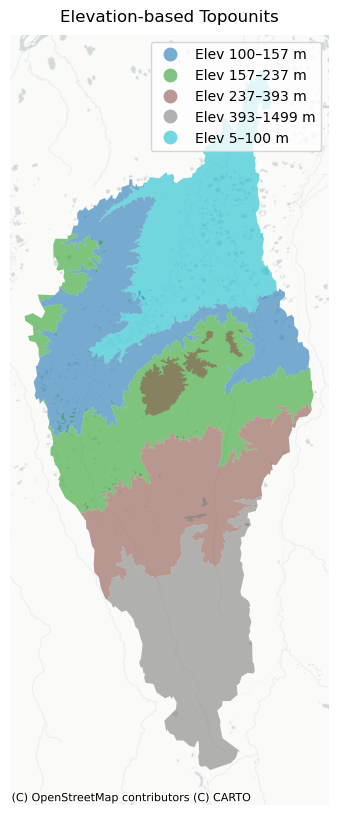

In [ ]:
# Static
gdfp = tplt.prepare_for_plot(topos_elev5, ndigits_numeric=0)
fig, ax = tplt.plot_static(gdfp, basemap="positron", edgecolor="none", linewidth=0)
ax.set_title("Elevation-based Topounits", pad=10)
plt.show()


In [ ]:
# Interactive visualization
m = tplt.plot_interactive(gdfp, tiles="CartoDB positron", style_kwds={"fillOpacity": 0.55, "weight": 0})
m  # display in notebook

## E. Binning options
Here, we look at how to specify different binning strategies. For example, you may want to specify your elevation bin ranges instead of just using equal-area (percentiles). Another difference here is that we will use "Height Above Nearest Drainage" (HAND) to delineate Topounits instead of elevation. `dapper` natively supports three built-in datasets you can use to design Topounits: `elev`, `aspect`, and `hand`, but a later section of this notebook will show you how to use *any* GEE image you want. The primary purpose of this section is to demonstrate how you can define different binning strategies for defining your Topounits. We'll do a `percentiles` example with 6 bins, and then a `fixed` example where we specify the bin edges but still use 6 bins total.

[HAND] Desired ~90.0 m → selected hand90_1000 @ ~92.76624232769086 m.
[Scale] planned bins=6, coarsest_native=92.8 m, analysis_scale=92.8 m
Success! FeatureCollection loaded as GeoDataFrame.
[HAND] Desired ~90.0 m → selected hand90_1000 @ ~92.76624232769086 m.
[Scale] planned bins=6, coarsest_native=92.8 m, analysis_scale=92.8 m
Success! FeatureCollection loaded as GeoDataFrame.


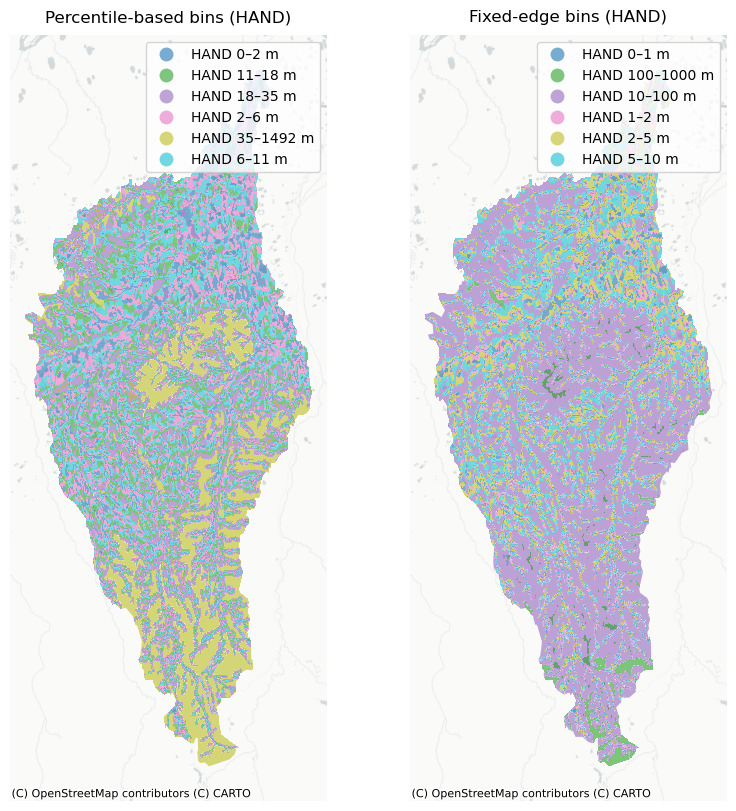

In [ ]:
# HAND percentiles (46 bins)
topos_hand4 = make_topounits(
    feature=feature,
    sources=['hand'],
    binning={'hand': {'strategy': 'percentiles', 'n_bins': 6, 'label_prefix': 'HAND'}},
    target_scale=90,
    verbose=True
)

# HAND fixed edges (meters) → note edges > 100 prefer *_1000 HAND internally
hand_edges = [0, 1, 2, 5, 10, 100, 1000]
topos_hand_fixed = make_topounits(
    feature=feature,
    sources=['hand'],
    binning={'hand': {'strategy': 'fixed', 'edges': hand_edges, 'label_prefix': 'HAND'}},
    target_scale=90,
    verbose=True
)

# Plot both side-by-side
gdfp_pct  = tplt.prepare_for_plot(topos_hand4,       ndigits_numeric=0, order=['hand'])
gdfp_fix  = tplt.prepare_for_plot(topos_hand_fixed,  ndigits_numeric=0, order=['hand'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8), constrained_layout=True)

# Left: percentiles
tplt.plot_static(
    gdfp_pct,
    basemap="positron",
    edgecolor="none",
    linewidth=0,
    legend=True,        # turn off duplicate legends
    ax=ax1
)
ax1.set_title("Percentile-based bins (HAND)", pad=10)

# Right: fixed edges
tplt.plot_static(
    gdfp_fix,
    basemap="positron",
    edgecolor="none",
    linewidth=0,
    legend=True,
    ax=ax2
)
ax2.set_title("Fixed-edge bins (HAND)", pad=10)

plt.show()

We can see that using percentile-based bins results in Topounits that are approximately equal-area (well, it's kind of hard to see on this plot, but you can look at the areas in the `GeoDataFrame`). Comparing to the fixed-bins on the right, we clearly see more of an area imbalance (HAND 10-100 m contains the majority of the watershed's area).

## F. Use your own dataset (GEE image)

You may want to experiment with some other dataset that `dapper` doesn't natively support to define Topounit boundaries. This example shows you how to do this. Note that the support for this is fairly basic--you must provide an `ee.Image()` (or something that behaves like one) and there isn't a ton of code under the hood to help you identify and fix problems with your supplied image. The neat thing about this feature is that you can use GEE to build an image that is derived. For example, maybe you want Topounits based on the average annual air temperature. You can make that image using ERA5 (or any meteorological dataset), export it as a GEE Asset, then point to it here. Or you could build it using the Python API and completely skip any exporting step. Here, we're just going to point to a [user-uploaded dataset](https://gee-community-catalog.org/projects/hydro90/#earth-engine-snippet-stream-outlet-distance) called the *compound topographic index* (which is the same as the topographic wetness index). 

[SRC CTI] custom image, native_scale≈1000.0 m
[Scale] planned bins=3, coarsest_native=1000.0 m, analysis_scale=1000.0 m
Success! FeatureCollection loaded as GeoDataFrame.


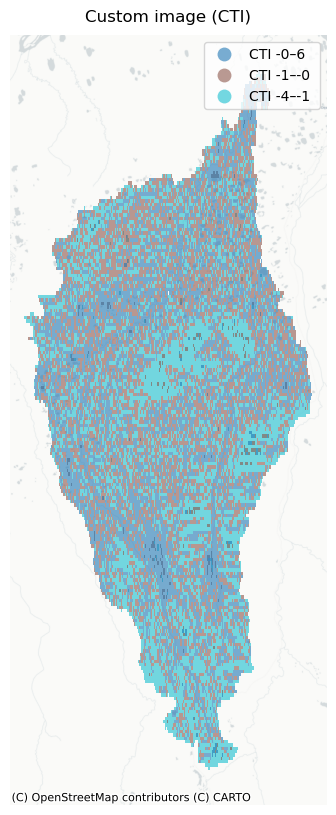

In [ ]:
# Note that we're using mosaic() to put all the images in the ImageCollection into one, then select(0) as a safety
# mechanism to make sure we only have a single image. We also know from the CTI documentation that the values are
# stored as ints and scaled by 10^8. So we convert them. These details just highlight that you'll need to figure 
# out the appropriate strategy for whatever data/image you want to use.
my_img = ee.ImageCollection("projects/sat-io/open-datasets/HYDROGRAPHY90/flow_index/cti").mosaic().select(0).toFloat().divide(1e8)

topos_custom = make_topounits(
    feature=feature,
    sources=['CTI'],
    binning={
        'CTI': {
            'image': my_img,                   # <- REQUIRED: single-band ee.Image
            'strategy': 'percentiles',         # or 'equalwidth' / 'fixed'
            'n_bins': 3,
            'label_prefix': 'CTI',
            'name': 'Compound Topographic Index',
            'units': 'unitless'                # cosmetic (for legend)
        }
    },
    target_scale=1000, # coarser scale for faster results
    export_scale=1000, # coarser scale for smaller filesize 
    verbose=True
)

gdfp = tplt.prepare_for_plot(topos_custom, ndigits_numeric=0)
fig, ax = tplt.plot_static(gdfp, basemap="positron", edgecolor="none", linewidth=0)
ax.set_title("Custom image (CTI)", pad=10)
plt.show()


## G. Combining datasets to define Topounits
We might want to define Topounits based on more than one variable. This example shows how to combine elevation *and* aspect to make Topounits. We consider two aspect classes (North- and South-facing) and four equal-area elevation bins. This will result in 8 Topounits (2 x 4)

[SRC elev] native_scale≈2.0 m
[SRC aspect] derived from DEM, native_scale≈2.0 m
[Scale] planned bins=8, coarsest_native=2.0 m, analysis_scale=90.0 m
Success! FeatureCollection loaded as GeoDataFrame.


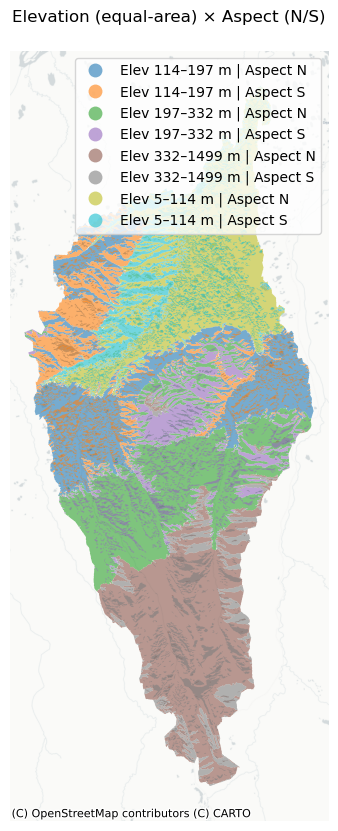

In [ ]:
# NOTE: Aspect bins are wrap-aware: start > end means it crosses 360→0.
aspects = [(270, 90, 'N'), (90.01, 269.99, 'S')]

gdf_elev_aspect_ns = make_topounits(
    feature=feature,
    sources=['elev', 'aspect'],
    binning={
        'elev':   {'strategy': 'percentiles', 'n_bins': 4, 'label_prefix': 'ELEV'},  # equal-area elevation bins
        'aspect': {'strategy': 'fixed', 'ranges': aspects, 'label_prefix': 'ASP'}    # fixed N/S aspect bins
    },
    combine='cartesian',      # 4 × 2 = 8 bins
    min_patch_pixels=9,       # optional cleanup of tiny slivers
    export_scale='native',
    target_scale=90,          # keeps analysis sane for big AOIs
    verbose=True
)

# Prepare labels + area (order controls how combined legend strings are composed)
gdfp = tplt.prepare_for_plot(gdf_elev_aspect_ns, ndigits_numeric=0, order=['elev', 'aspect'])

# Static basemap
import matplotlib.pyplot as plt
fig, ax = tplt.plot_static(
    gdfp,
    basemap="positron",
    edgecolor="none",
    linewidth=0
)
ax.set_title("Elevation (equal-area) × Aspect (N/S)", pad=10)
plt.show()
